In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("data/bitcoin.csv")

df.head()

,Date,Open,High,Low,Close,Volume,PriceCategory
0,2010-01-01,0.3,0.303428,0.295510,0.3,715.8,Low
1,2010-01-02,0.3,0.304377,0.299459,0.3,2028.3,Low
2,2010-01-03,0.3,0.303736,0.295858,0.3,273.0,Low
3,2010-01-04,0.3,0.303406,0.298489,0.3,1452.0,Low
4,2010-01-05,0.3,0.302715,0.296330,0.3,1002.6,Low


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5883 entries, 0 to 5882
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           5883 non-null   str    
 1   Open           5883 non-null   float64
 2   High           5883 non-null   float64
 3   Low            5883 non-null   float64
 4   Close          5883 non-null   float64
 5   Volume         5883 non-null   float64
 6   PriceCategory  5883 non-null   str    
dtypes: float64(5), str(2)
memory usage: 321.9 KB


In [4]:
df.isnull().sum()

Date             0
Open             0
High             0
Low              0
Close            0
Volume           0
PriceCategory    0
dtype: int64

In [5]:
# Remove the PriceCategory column
df = df.drop(columns=["PriceCategory"])

# Display the first 5 rows
df.head()

,Date,Open,High,Low,Close,Volume
0,2010-01-01,0.3,0.303428,0.295510,0.3,715.8
1,2010-01-02,0.3,0.304377,0.299459,0.3,2028.3
2,2010-01-03,0.3,0.303736,0.295858,0.3,273.0
3,2010-01-04,0.3,0.303406,0.298489,0.3,1452.0
4,2010-01-05,0.3,0.302715,0.296330,0.3,1002.6


In [6]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df.reset_index(drop=True, inplace=True)

df.head()

,Date,Open,High,Low,Close,Volume
0,2010-01-01,0.3,0.303428,0.295510,0.3,715.8
1,2010-01-02,0.3,0.304377,0.299459,0.3,2028.3
2,2010-01-03,0.3,0.303736,0.295858,0.3,273.0
3,2010-01-04,0.3,0.303406,0.298489,0.3,1452.0
4,2010-01-05,0.3,0.302715,0.296330,0.3,1002.6


In [7]:
# Tomorrow's closing price
df["Tomorrow_Close"] = df["Close"].shift(-1)

# Target:
# 1 = Tomorrow's price is higher
# 0 = Tomorrow's price is lower or equal
df["Target"] = (df["Tomorrow_Close"] > df["Close"]).astype(int)

df.head(10)

,Date,Open,High,Low,Close,Volume,Tomorrow_Close,Target
0,2010-01-01,0.3,0.303428,0.295510,0.3,715.8,0.3,0
1,2010-01-02,0.3,0.304377,0.299459,0.3,2028.3,0.3,0
2,2010-01-03,0.3,0.303736,0.295858,0.3,273.0,0.3,0
3,2010-01-04,0.3,0.303406,0.298489,0.3,1452.0,0.3,0
4,2010-01-05,0.3,0.302715,0.296330,0.3,1002.6,0.3,0
5,2010-01-06,0.3,0.303982,0.298127,0.3,872.7,0.3,0
6,2010-01-07,0.3,0.302794,0.299572,0.3,421.2,0.3,0
7,2010-01-08,0.3,0.305383,0.295792,0.3,1030.5,0.3,0
8,2010-01-09,0.3,0.305793,0.297143,0.3,2379.9,0.3,0
9,2010-01-10,0.3,0.302486,0.295572,0.3,310.5,0.3,0


In [8]:
df = df.dropna()

df.tail()

,Date,Open,High,Low,Close,Volume,Tomorrow_Close,Target
5877,2026-02-03,69000.0,70374.381304,68814.408263,69000.0,404616000.0,69000.0,0
5878,2026-02-04,69000.0,70144.883975,68886.645749,69000.0,343137000.0,69000.0,0
5879,2026-02-05,69000.0,70283.613241,67999.266453,69000.0,344379000.0,69000.0,0
5880,2026-02-06,69000.0,69305.587376,67958.233281,69000.0,524676000.0,69000.0,0
5881,2026-02-07,69000.0,69888.021412,68314.343334,69000.0,117852000.0,69000.0,0


In [9]:
df["Target"].value_counts()

Target
0    5871
1      11
Name: count, dtype: int64

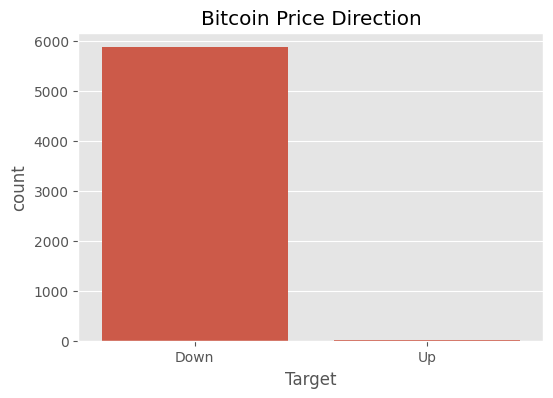

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Target")

plt.title("Bitcoin Price Direction")

plt.xticks([0,1], ["Down", "Up"])

plt.show()

In [11]:
# Calculate the daily percentage return
df["Daily_Return"] = df["Close"].pct_change()

df.head()

,Date,Open,High,Low,Close,Volume,Tomorrow_Close,Target,Daily_Return
0,2010-01-01,0.3,0.303428,0.295510,0.3,715.8,0.3,0,NaN
1,2010-01-02,0.3,0.304377,0.299459,0.3,2028.3,0.3,0,0.0
2,2010-01-03,0.3,0.303736,0.295858,0.3,273.0,0.3,0,0.0
3,2010-01-04,0.3,0.303406,0.298489,0.3,1452.0,0.3,0,0.0
4,2010-01-05,0.3,0.302715,0.296330,0.3,1002.6,0.3,0,0.0


In [12]:
# Simple Moving Averages
df["SMA_10"] = df["Close"].rolling(window=10).mean()
df["SMA_20"] = df["Close"].rolling(window=20).mean()

df.head(20)

,Date,Open,High,Low,Close,Volume,Tomorrow_Close,Target,Daily_Return,SMA_10,SMA_20
0,2010-01-01,0.3,0.303428,0.295510,0.3,715.8,0.3,0,NaN,NaN,NaN
1,2010-01-02,0.3,0.304377,0.299459,0.3,2028.3,0.3,0,0.0,NaN,NaN
2,2010-01-03,0.3,0.303736,0.295858,0.3,273.0,0.3,0,0.0,NaN,NaN
3,2010-01-04,0.3,0.303406,0.298489,0.3,1452.0,0.3,0,0.0,NaN,NaN
4,2010-01-05,0.3,0.302715,0.296330,0.3,1002.6,0.3,0,0.0,NaN,NaN
5,2010-01-06,0.3,0.303982,0.298127,0.3,872.7,0.3,0,0.0,NaN,NaN
6,2010-01-07,0.3,0.302794,0.299572,0.3,421.2,0.3,0,0.0,NaN,NaN
7,2010-01-08,0.3,0.305383,0.295792,0.3,1030.5,0.3,0,0.0,NaN,NaN
8,2010-01-09,0.3,0.305793,0.297143,0.3,2379.9,0.3,0,0.0,NaN,NaN
9,2010-01-10,0.3,0.302486,0.295572,0.3,310.5,0.3,0,0.0,0.3,NaN


In [13]:
# Exponential Moving Average
df["EMA_10"] = df["Close"].ewm(span=10, adjust=False).mean()

df.head(20)

,Date,Open,High,Low,Close,Volume,Tomorrow_Close,Target,Daily_Return,SMA_10,SMA_20,EMA_10
0,2010-01-01,0.3,0.303428,0.295510,0.3,715.8,0.3,0,NaN,NaN,NaN,0.3
1,2010-01-02,0.3,0.304377,0.299459,0.3,2028.3,0.3,0,0.0,NaN,NaN,0.3
2,2010-01-03,0.3,0.303736,0.295858,0.3,273.0,0.3,0,0.0,NaN,NaN,0.3
3,2010-01-04,0.3,0.303406,0.298489,0.3,1452.0,0.3,0,0.0,NaN,NaN,0.3
4,2010-01-05,0.3,0.302715,0.296330,0.3,1002.6,0.3,0,0.0,NaN,NaN,0.3
5,2010-01-06,0.3,0.303982,0.298127,0.3,872.7,0.3,0,0.0,NaN,NaN,0.3
6,2010-01-07,0.3,0.302794,0.299572,0.3,421.2,0.3,0,0.0,NaN,NaN,0.3
7,2010-01-08,0.3,0.305383,0.295792,0.3,1030.5,0.3,0,0.0,NaN,NaN,0.3
8,2010-01-09,0.3,0.305793,0.297143,0.3,2379.9,0.3,0,0.0,NaN,NaN,0.3
9,2010-01-10,0.3,0.302486,0.295572,0.3,310.5,0.3,0,0.0,0.3,NaN,0.3


In [14]:
# Difference between High and Low prices
df["High_Low"] = df["High"] - df["Low"]

df.head()

,Date,Open,High,Low,Close,Volume,Tomorrow_Close,Target,Daily_Return,SMA_10,SMA_20,EMA_10,High_Low
0,2010-01-01,0.3,0.303428,0.295510,0.3,715.8,0.3,0,NaN,NaN,NaN,0.3,0.007919
1,2010-01-02,0.3,0.304377,0.299459,0.3,2028.3,0.3,0,0.0,NaN,NaN,0.3,0.004917
2,2010-01-03,0.3,0.303736,0.295858,0.3,273.0,0.3,0,0.0,NaN,NaN,0.3,0.007878
3,2010-01-04,0.3,0.303406,0.298489,0.3,1452.0,0.3,0,0.0,NaN,NaN,0.3,0.004916
4,2010-01-05,0.3,0.302715,0.296330,0.3,1002.6,0.3,0,0.0,NaN,NaN,0.3,0.006385


In [15]:
# Rolling volatility over 10 days
df["Volatility"] = df["Daily_Return"].rolling(window=10).std()

df.head(20)

,Date,Open,High,Low,Close,Volume,Tomorrow_Close,Target,Daily_Return,SMA_10,SMA_20,EMA_10,High_Low,Volatility
0,2010-01-01,0.3,0.303428,0.295510,0.3,715.8,0.3,0,NaN,NaN,NaN,0.3,0.007919,NaN
1,2010-01-02,0.3,0.304377,0.299459,0.3,2028.3,0.3,0,0.0,NaN,NaN,0.3,0.004917,NaN
2,2010-01-03,0.3,0.303736,0.295858,0.3,273.0,0.3,0,0.0,NaN,NaN,0.3,0.007878,NaN
3,2010-01-04,0.3,0.303406,0.298489,0.3,1452.0,0.3,0,0.0,NaN,NaN,0.3,0.004916,NaN
4,2010-01-05,0.3,0.302715,0.296330,0.3,1002.6,0.3,0,0.0,NaN,NaN,0.3,0.006385,NaN
5,2010-01-06,0.3,0.303982,0.298127,0.3,872.7,0.3,0,0.0,NaN,NaN,0.3,0.005855,NaN
6,2010-01-07,0.3,0.302794,0.299572,0.3,421.2,0.3,0,0.0,NaN,NaN,0.3,0.003222,NaN
7,2010-01-08,0.3,0.305383,0.295792,0.3,1030.5,0.3,0,0.0,NaN,NaN,0.3,0.009591,NaN
8,2010-01-09,0.3,0.305793,0.297143,0.3,2379.9,0.3,0,0.0,NaN,NaN,0.3,0.008650,NaN
9,2010-01-10,0.3,0.302486,0.295572,0.3,310.5,0.3,0,0.0,0.3,NaN,0.3,0.006914,NaN


In [16]:
df = df.dropna()

df.reset_index(drop=True, inplace=True)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5863 entries, 0 to 5862
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            5863 non-null   datetime64[us]
 1   Open            5863 non-null   float64       
 2   High            5863 non-null   float64       
 3   Low             5863 non-null   float64       
 4   Close           5863 non-null   float64       
 5   Volume          5863 non-null   float64       
 6   Tomorrow_Close  5863 non-null   float64       
 7   Target          5863 non-null   int64         
 8   Daily_Return    5863 non-null   float64       
 9   SMA_10          5863 non-null   float64       
 10  SMA_20          5863 non-null   float64       
 11  EMA_10          5863 non-null   float64       
 12  High_Low        5863 non-null   float64       
 13  Volatility      5863 non-null   float64       
dtypes: datetime64[us](1), float64(12), int64(1)
memory usage: 641.4 KB


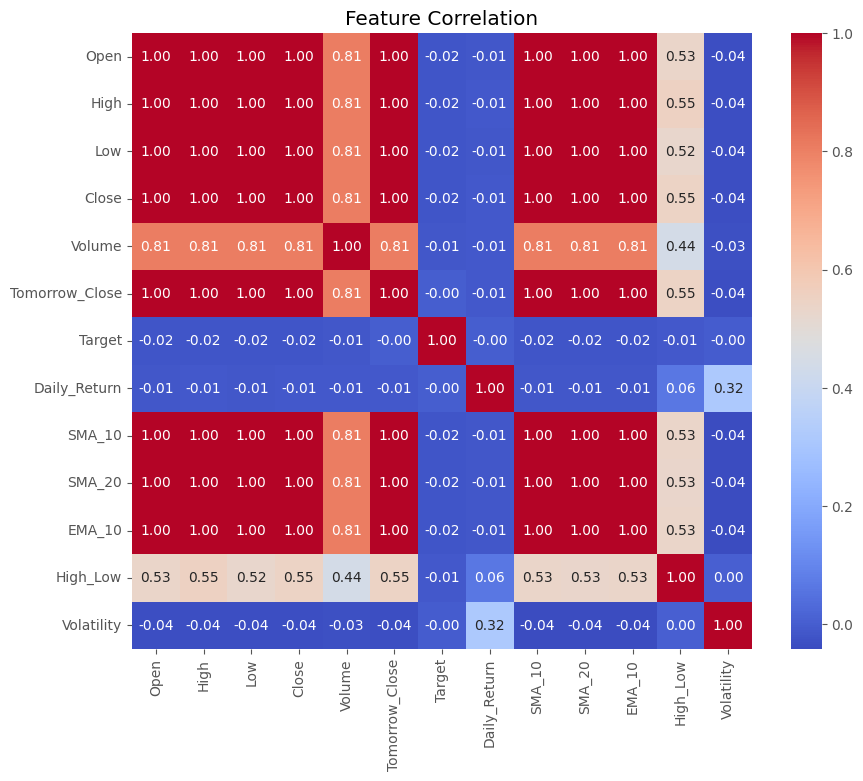

In [17]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Feature Correlation")

plt.show()

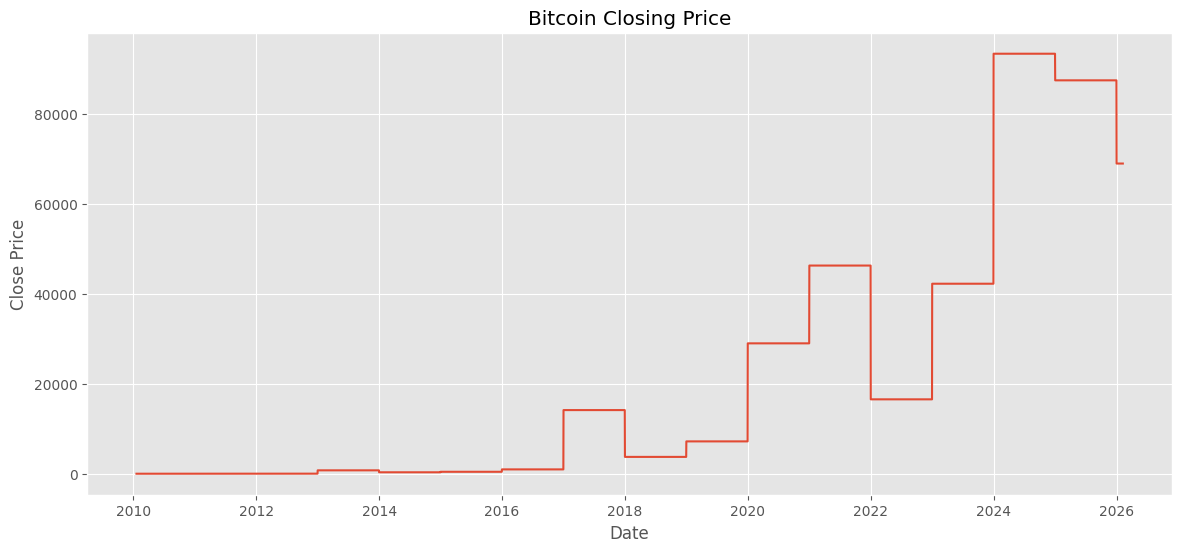

In [18]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Close"])

plt.title("Bitcoin Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()

In [19]:
# Features used for prediction
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Daily_Return",
    "SMA_10",
    "SMA_20",
    "EMA_10",
    "High_Low",
    "Volatility"
]

X = df[features]
y = df["Target"]

X.head()

,Open,High,Low,Close,Volume,Daily_Return,SMA_10,SMA_20,EMA_10,High_Low,Volatility
0,0.3,0.305259,0.294890,0.3,158.4,0.0,0.3,0.3,0.3,0.010369,0.0
1,0.3,0.305878,0.296337,0.3,957.0,0.0,0.3,0.3,0.3,0.009541,0.0
2,0.3,0.304855,0.295184,0.3,1566.6,0.0,0.3,0.3,0.3,0.009672,0.0
3,0.3,0.302930,0.298234,0.3,1254.0,0.0,0.3,0.3,0.3,0.004697,0.0
4,0.3,0.304749,0.296130,0.3,2197.8,0.0,0.3,0.3,0.3,0.008619,0.0


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4690
Testing samples: 1173


In [21]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_predictions = log_model.predict(X_test)

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, log_predictions))

Logistic Regression Accuracy:
0.9872122762148338


c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [22]:
tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

print("Decision Tree Accuracy:")
print(accuracy_score(y_test, tree_predictions))

Decision Tree Accuracy:
0.9982949701619779


In [23]:
forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest_model.fit(X_train, y_train)

forest_predictions = forest_model.predict(X_test)

print("Random Forest Accuracy:")
print(accuracy_score(y_test, forest_predictions))

Random Forest Accuracy:
0.9982949701619779


In [24]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_predictions),
        accuracy_score(y_test, tree_predictions),
        accuracy_score(y_test, forest_predictions)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
1,Decision Tree,0.998295
2,Random Forest,0.998295
0,Logistic Regression,0.987212


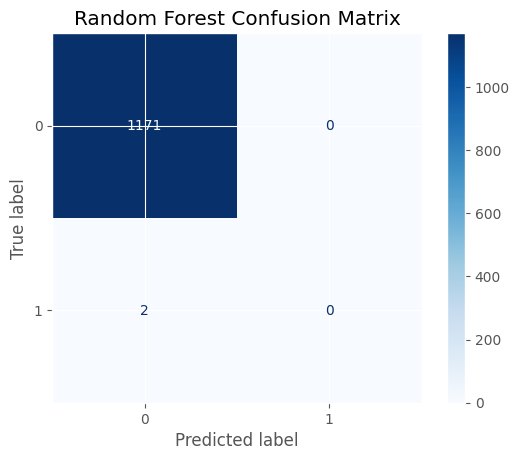

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    forest_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [26]:
print(classification_report(y_test, forest_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1171
           1       0.00      0.00      0.00         2

    accuracy                           1.00      1173
   macro avg       0.50      0.50      0.50      1173
weighted avg       1.00      1.00      1.00      1173



c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [27]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": forest_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,High,0.251154
2,Low,0.248907
9,High_Low,0.232660
4,Volume,0.223237
8,EMA_10,0.014232
0,Open,0.010037
7,SMA_20,0.006825
3,Close,0.006036
6,SMA_10,0.005887
10,Volatility,0.000516


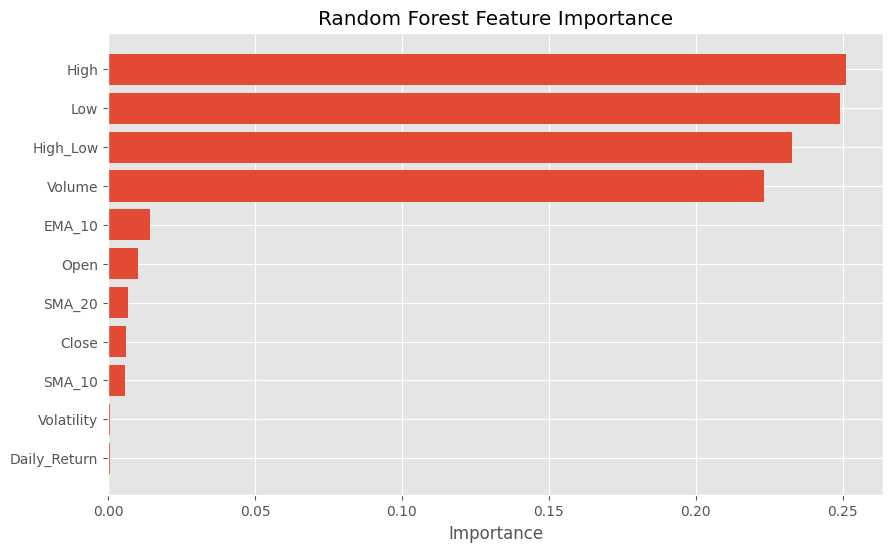

In [28]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [29]:
sample = X_test.iloc[[0]]

prediction = forest_model.predict(sample)

if prediction[0] == 1:
    print("Prediction: Tomorrow's Bitcoin price will go UP 📈")
else:
    print("Prediction: Tomorrow's Bitcoin price will go DOWN 📉")

Prediction: Tomorrow's Bitcoin price will go DOWN 📉


In [30]:
# Last sample in the test set
sample = X_test.iloc[[-1]]

prediction = forest_model.predict(sample)[0]

actual = y_test.iloc[-1]

print("Prediction:", "UP 📈" if prediction == 1 else "DOWN 📉")
print("Actual:", "UP 📈" if actual == 1 else "DOWN 📉")

Prediction: DOWN 📉
Actual: DOWN 📉


In [31]:
predictions = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": forest_predictions
})

predictions["Actual"] = predictions["Actual"].map({1: "UP 📈", 0: "DOWN 📉"})
predictions["Predicted"] = predictions["Predicted"].map({1: "UP 📈", 0: "DOWN 📉"})

predictions.head(20)

,Actual,Predicted
0,DOWN 📉,DOWN 📉
1,DOWN 📉,DOWN 📉
2,DOWN 📉,DOWN 📉
3,DOWN 📉,DOWN 📉
4,DOWN 📉,DOWN 📉
5,DOWN 📉,DOWN 📉
6,DOWN 📉,DOWN 📉
7,DOWN 📉,DOWN 📉
8,DOWN 📉,DOWN 📉
9,DOWN 📉,DOWN 📉


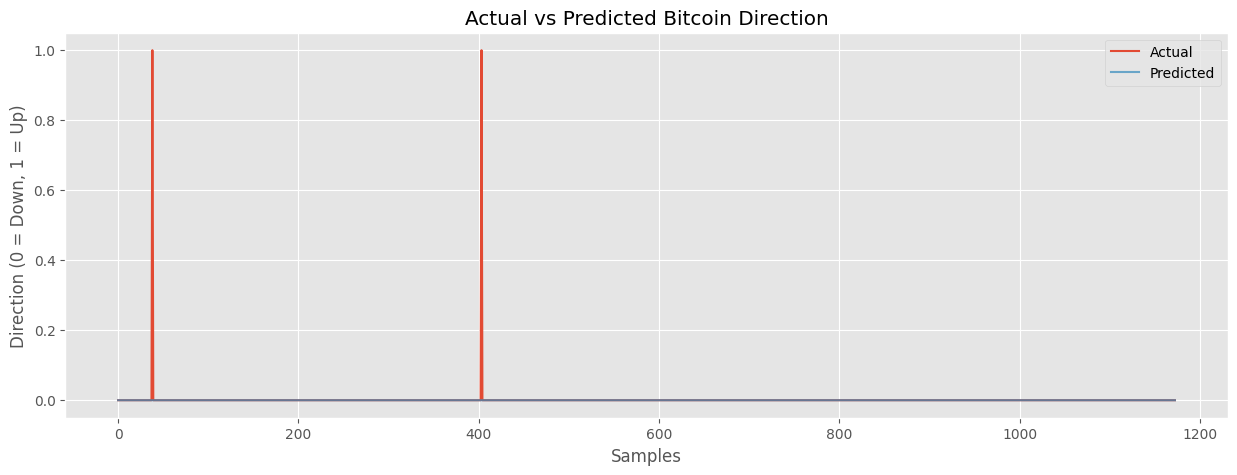

In [32]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": forest_predictions
})

plt.figure(figsize=(15,5))

plt.plot(comparison["Actual"].values, label="Actual")
plt.plot(comparison["Predicted"].values, label="Predicted", alpha=0.7)

plt.title("Actual vs Predicted Bitcoin Direction")
plt.xlabel("Samples")
plt.ylabel("Direction (0 = Down, 1 = Up)")
plt.legend()

plt.show()

In [33]:
# December 8 closing price
dec8 = df[df["Date"] == "2023-12-01"]["Close"].values[0]

# December 9 closing price
dec9 = df[df["Date"] == "2023-12-09"]["Close"].values[0]

print(f"Closing Price (2023-12-08): ${dec8:,.2f}")
print(f"Closing Price (2023-12-09): ${dec9:,.2f}")

if dec9 > dec8:
    print("\nActual Market Movement: UP 📈")
else:
    print("\nActual Market Movement: DOWN 📉")

Closing Price (2023-12-08): $42,265.19
Closing Price (2023-12-09): $42,265.19

Actual Market Movement: DOWN 📉


In [34]:
df[df["Date"].between("2025-12-01", "2025-12-10")]

,Date,Open,High,Low,Close,Volume,Tomorrow_Close,Target,Daily_Return,SMA_10,SMA_20,EMA_10,High_Low,Volatility
5794,2025-12-01,87508.83,88239.658230,86647.097066,87508.83,7.701652e+08,87508.83,0,0.0,87508.83,87508.83,87508.83,1592.561163,0.0
5795,2025-12-02,87508.83,88899.994440,86148.389384,87508.83,1.198871e+08,87508.83,0,0.0,87508.83,87508.83,87508.83,2751.605056,0.0
5796,2025-12-03,87508.83,88729.865523,86599.280866,87508.83,5.530558e+07,87508.83,0,0.0,87508.83,87508.83,87508.83,2130.584657,0.0
5797,2025-12-04,87508.83,88994.430806,86293.974260,87508.83,4.199549e+08,87508.83,0,0.0,87508.83,87508.83,87508.83,2700.456546,0.0
5798,2025-12-05,87508.83,88346.980563,86052.732249,87508.83,4.709725e+08,87508.83,0,0.0,87508.83,87508.83,87508.83,2294.248314,0.0
5799,2025-12-06,87508.83,87802.961846,86293.567024,87508.83,8.294087e+08,87508.83,0,0.0,87508.83,87508.83,87508.83,1509.394823,0.0
5800,2025-12-07,87508.83,88465.290961,86815.824798,87508.83,8.111193e+08,87508.83,0,0.0,87508.83,87508.83,87508.83,1649.466163,0.0
5801,2025-12-08,87508.83,87661.997597,86625.829349,87508.83,5.070262e+08,87508.83,0,0.0,87508.83,87508.83,87508.83,1036.168248,0.0
5802,2025-12-09,87508.83,88312.729862,86646.128013,87508.83,5.128017e+07,87508.83,0,0.0,87508.83,87508.83,87508.83,1666.601849,0.0
5803,2025-12-10,87508.83,87931.228153,85826.375290,87508.83,3.976401e+08,87508.83,0,0.0,87508.83,87508.83,87508.83,2104.852863,0.0


In [35]:
df[df["Date"].between("2026-07-16", "2026-07-17")]

,Date,Open,High,Low,Close,Volume,Tomorrow_Close,Target,Daily_Return,SMA_10,SMA_20,EMA_10,High_Low,Volatility


In [36]:
new_data = pd.DataFrame({
    "Open": [44200],
    "High": [44650],
    "Low": [43800],
    "Close": [44410],
    "Volume": [21500],
    "Daily_Return": [0.012],
    "SMA_10": [43500],
    "SMA_20": [42800],
    "EMA_10": [43750],
    "High_Low": [850],
    "Volatility": [0.028]
})

In [37]:
prediction = forest_model.predict(new_data)

print(prediction)


[0]


In [38]:
df["Date"].min(), df["Date"].max()


(Timestamp('2010-01-20 00:00:00'), Timestamp('2026-02-07 00:00:00'))

In [39]:
prediction = forest_model.predict(new_data)

print(prediction)


[0]
